In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [19]:
# Loading Boston Housing dataset from tf.keras.datasets
# This is a regression dataset.

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.boston_housing.load_data()

print("Raw Training Features Shape:", X_train_raw.shape)
print("Raw Training Target Shape:", y_train_raw.shape)
print("Raw Test Features Shape:", X_test_raw.shape)
print("Raw Test Target Shape:", y_test_raw.shape)

Raw Training Features Shape: (404, 13)
Raw Training Target Shape: (404,)
Raw Test Features Shape: (102, 13)
Raw Test Target Shape: (102,)


In [20]:
# Combine training and testing data first
# Then we will normalize and create sequences

X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)

print("Complete Feature Dataset Shape:", X_all.shape)
print("Complete Target Dataset Shape:", y_all.shape)

Complete Feature Dataset Shape: (506, 13)
Complete Target Dataset Shape: (506,)


In [21]:
# Normalize features
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X_all)

# Normalize target values
target_scaler = StandardScaler()
y_scaled = target_scaler.fit_transform(y_all.reshape(-1, 1)).flatten()

print("Scaled Features Shape:", X_scaled.shape)
print("Scaled Target Shape:", y_scaled.shape)

Scaled Features Shape: (506, 13)
Scaled Target Shape: (506,)


In [22]:
# Sequence length means how many previous records are used to predict the next value
sequence_length = 10

X_sequences = []
y_sequences = []

for i in range(len(X_scaled) - sequence_length):
    X_sequences.append(X_scaled[i:i + sequence_length])
    y_sequences.append(y_scaled[i + sequence_length])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("Input Sequence Shape:", X_sequences.shape)
print("Output Target Shape:", y_sequences.shape)

Input Sequence Shape: (496, 10, 13)
Output Target Shape: (496,)


In [23]:
total_samples = len(X_sequences)

train_size = int(total_samples * 0.70)
validation_size = int(total_samples * 0.15)

X_train = X_sequences[:train_size]
y_train = y_sequences[:train_size]

X_val = X_sequences[train_size:train_size + validation_size]
y_val = y_sequences[train_size:train_size + validation_size]

X_test = X_sequences[train_size + validation_size:]
y_test = y_sequences[train_size + validation_size:]

print("Training Data Shape:", X_train.shape, y_train.shape)
print("Validation Data Shape:", X_val.shape, y_val.shape)
print("Test Data Shape:", X_test.shape, y_test.shape)

Training Data Shape: (347, 10, 13) (347,)
Validation Data Shape: (74, 10, 13) (74,)
Test Data Shape: (75, 10, 13) (75,)


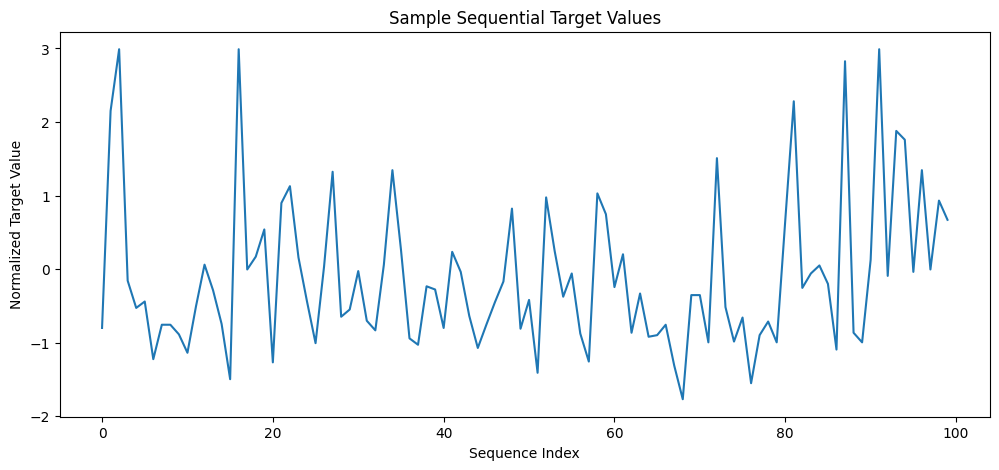

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(y_scaled[:100])

plt.title("Sample Sequential Target Values")
plt.xlabel("Sequence Index")
plt.ylabel("Normalized Target Value")
plt.show()

In [25]:
input_shape = (X_train.shape[1], X_train.shape[2])

In [26]:
def build_rnn_model(input_shape):
    model = keras.Sequential([
        layers.SimpleRNN(64, activation='tanh', input_shape=input_shape),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


rnn_model = build_rnn_model(input_shape)
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,105 (27.75 KB)

 Trainable params: 7,105 (27.75 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    verbose=1
)

rnn_time = time.time() - start_time

print("RNN Training Time:", rnn_time, "seconds")

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.3133 - mae: 0.8583 - val_loss: 0.8359 - val_mae: 0.6419
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9709 - mae: 0.7272 - val_loss: 0.8443 - val_mae: 0.6660
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8314 - mae: 0.6582 - val_loss: 0.8733 - val_mae: 0.6749
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7159 - mae: 0.6216 - val_loss: 0.9048 - val_mae: 0.6983
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4980 - mae: 0.5320 - val_loss: 0.9199 - val_mae: 0.7060
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4797 - mae: 0.5205 - val_loss: 0.9624 - val_mae: 0.7338
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5480 - mae: 0.5599 - val_loss: 0.9942 - val_mae: 0.7409
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3490 - mae: 0.4454 - val_loss: 1.0295 - val_mae: 0.7636
Epoch 9/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3244 - mae:

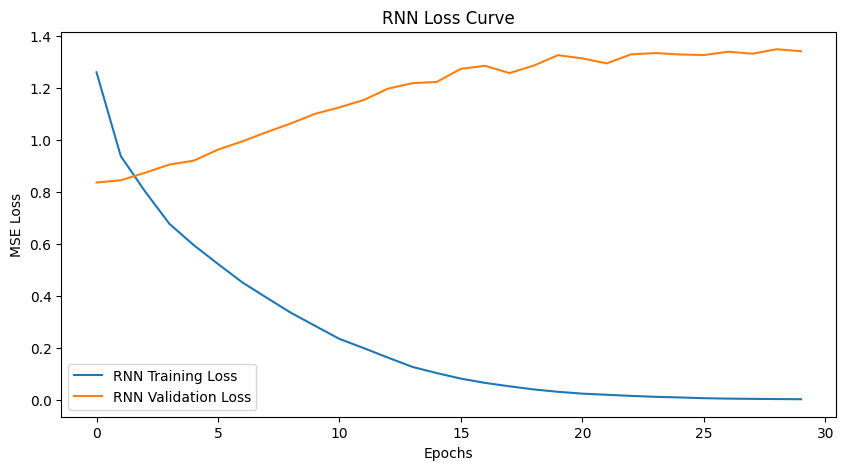

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(rnn_history.history['loss'], label='RNN Training Loss')
plt.plot(rnn_history.history['val_loss'], label='RNN Validation Loss')

plt.title("RNN Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [29]:
def build_lstm_model(input_shape):
    model = keras.Sequential([
        layers.LSTM(64, activation='tanh', input_shape=input_shape),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


lstm_model = build_lstm_model(input_shape)
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,081 (86.25 KB)

 Trainable params: 22,081 (86.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    verbose=1
)

lstm_time = time.time() - start_time

print("LSTM Training Time:", lstm_time, "seconds")

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1.2364 - mae: 0.8141 - val_loss: 0.5834 - val_mae: 0.5459
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0149 - mae: 0.7425 - val_loss: 0.5958 - val_mae: 0.5645
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8983 - mae: 0.6828 - val_loss: 0.6009 - val_mae: 0.5641
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9412 - mae: 0.7254 - val_loss: 0.5991 - val_mae: 0.5667
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9854 - mae: 0.7396 - val_loss: 0.5987 - val_mae: 0.5730
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8518 - mae: 0.6885 - val_loss: 0.6030 - val_mae: 0.5732
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8668 - mae: 0.6736 - val_loss: 0.6067 - val_mae: 0.5844
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8290 - mae: 0.6728 - val_loss: 0.6017 - val_mae: 0.5822
Epoch 9/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8094 - mae:

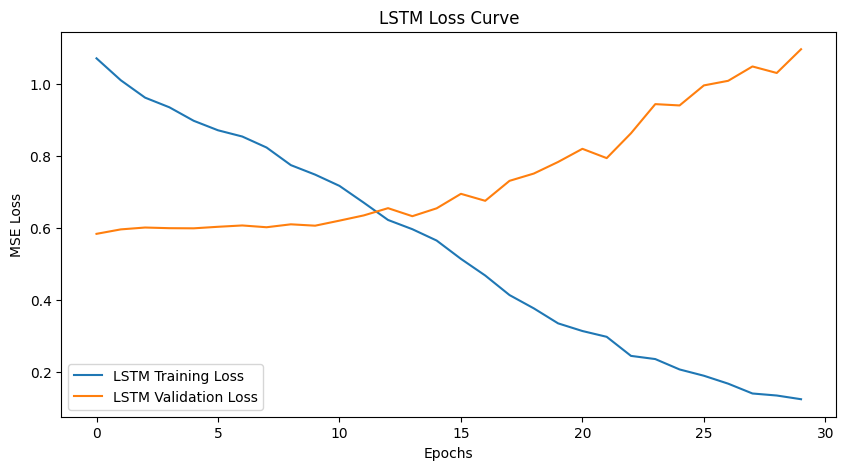

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(lstm_history.history['loss'], label='LSTM Training Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss')

plt.title("LSTM Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


In [32]:
def build_gru_model(input_shape):
    model = keras.Sequential([
        layers.GRU(64, activation='tanh', input_shape=input_shape),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


gru_model = build_gru_model(input_shape)
gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        15,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,281 (67.50 KB)

 Trainable params: 17,281 (67.50 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
start_time = time.time()

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    verbose=1
)

gru_time = time.time() - start_time

print("GRU Training Time:", gru_time, "seconds")

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1.2153 - mae: 0.8042 - val_loss: 0.6756 - val_mae: 0.6058
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9273 - mae: 0.6887 - val_loss: 0.6500 - val_mae: 0.5892
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0380 - mae: 0.7453 - val_loss: 0.6582 - val_mae: 0.6036
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8698 - mae: 0.6821 - val_loss: 0.6650 - val_mae: 0.6145
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8102 - mae: 0.6504 - val_loss: 0.6621 - val_mae: 0.6154
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9586 - mae: 0.7245 - val_loss: 0.6648 - val_mae: 0.6250
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8313 - mae: 0.6784 - val_loss: 0.6611 - val_mae: 0.6230
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7312 - mae: 0.6300 - val_loss: 0.6677 - val_mae: 0.6361
Epoch 9/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7320 - mae:

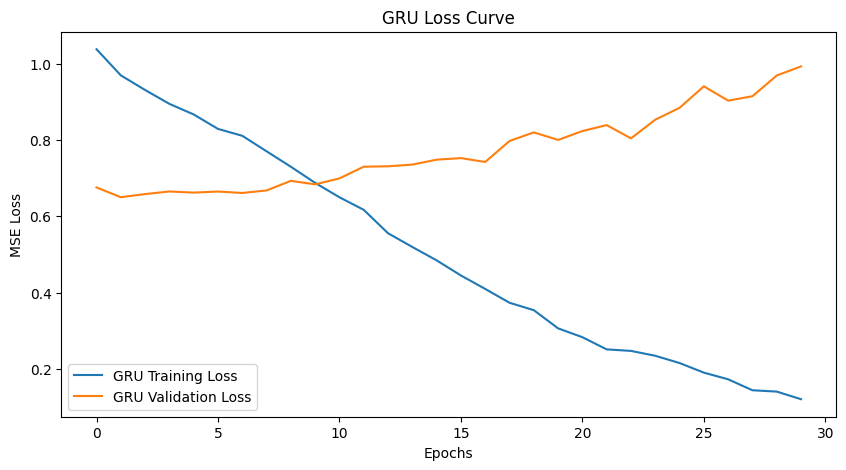

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(gru_history.history['loss'], label='GRU Training Loss')
plt.plot(gru_history.history['val_loss'], label='GRU Validation Loss')

plt.title("GRU Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [35]:
rnn_loss, rnn_mae = rnn_model.evaluate(X_test, y_test, verbose=0)
lstm_loss, lstm_mae = lstm_model.evaluate(X_test, y_test, verbose=0)
gru_loss, gru_mae = gru_model.evaluate(X_test, y_test, verbose=0)

print("RNN Test Loss:", rnn_loss)
print("RNN Test MAE:", rnn_mae)

print("LSTM Test Loss:", lstm_loss)
print("LSTM Test MAE:", lstm_mae)

print("GRU Test Loss:", gru_loss)
print("GRU Test MAE:", gru_mae)

RNN Test Loss: 1.7832458019256592
RNN Test MAE: 1.0205148458480835
LSTM Test Loss: 2.1647071838378906
LSTM Test MAE: 1.177837610244751
GRU Test Loss: 1.6049983501434326
GRU Test MAE: 0.9554653167724609


In [36]:
results = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "Test Loss MSE": [rnn_loss, lstm_loss, gru_loss],
    "Test MAE": [rnn_mae, lstm_mae, gru_mae],
    "Training Time Seconds": [rnn_time, lstm_time, gru_time]
})

results

,Model,Test Loss MSE,Test MAE,Training Time Seconds
0,Simple RNN,1.783246,1.020515,6.654327
1,LSTM,2.164707,1.177838,8.559398
2,GRU,1.604998,0.955465,8.970003


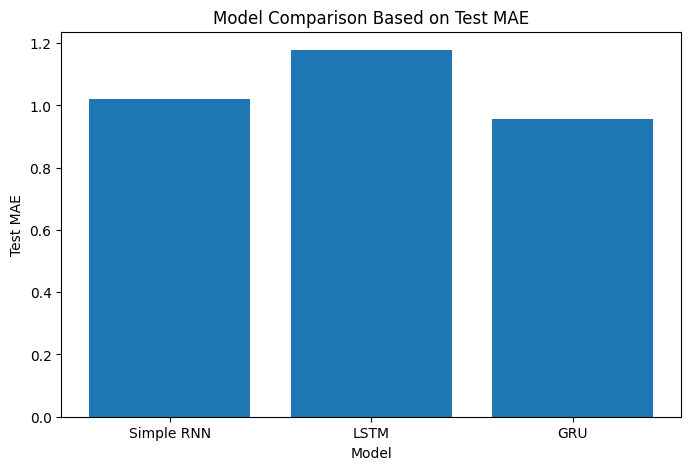

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Test MAE"])

plt.title("Model Comparison Based on Test MAE")
plt.xlabel("Model")
plt.ylabel("Test MAE")
plt.show()

In [38]:
rnn_predictions = rnn_model.predict(X_test)
lstm_predictions = lstm_model.predict(X_test)
gru_predictions = gru_model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7aebbb2f0f40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [39]:
y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

rnn_predictions_original = target_scaler.inverse_transform(rnn_predictions).flatten()
lstm_predictions_original = target_scaler.inverse_transform(lstm_predictions).flatten()
gru_predictions_original = target_scaler.inverse_transform(gru_predictions).flatten()

print("y_test_original created:", y_test_original.shape)
print("RNN predictions created:", rnn_predictions_original.shape)
print("LSTM predictions created:", lstm_predictions_original.shape)
print("GRU predictions created:", gru_predictions_original.shape)

y_test_original created: (75,)
RNN predictions created: (75,)
LSTM predictions created: (75,)
GRU predictions created: (75,)


In [40]:
rnn_rmse = np.sqrt(mean_squared_error(y_test_original, rnn_predictions_original))
lstm_rmse = np.sqrt(mean_squared_error(y_test_original, lstm_predictions_original))
gru_rmse = np.sqrt(mean_squared_error(y_test_original, gru_predictions_original))

rnn_mae_original = mean_absolute_error(y_test_original, rnn_predictions_original)
lstm_mae_original = mean_absolute_error(y_test_original, lstm_predictions_original)
gru_mae_original = mean_absolute_error(y_test_original, gru_predictions_original)

rnn_r2 = r2_score(y_test_original, rnn_predictions_original)
lstm_r2 = r2_score(y_test_original, lstm_predictions_original)
gru_r2 = r2_score(y_test_original, gru_predictions_original)

final_results = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "Test Loss MSE": [rnn_loss, lstm_loss, gru_loss],
    "MAE Original Scale": [rnn_mae_original, lstm_mae_original, gru_mae_original],
    "RMSE Original Scale": [rnn_rmse, lstm_rmse, gru_rmse],
    "R2 Score": [rnn_r2, lstm_r2, gru_r2],
    "Training Time Seconds": [rnn_time, lstm_time, gru_time]
})

final_results

,Model,Test Loss MSE,MAE Original Scale,RMSE Original Scale,R2 Score,Training Time Seconds
0,Simple RNN,1.783246,9.376502,12.269508,-0.644803,6.654327
1,LSTM,2.164707,10.821985,13.518270,-0.996649,8.559398
2,GRU,1.604998,8.778826,11.640157,-0.480393,8.970003


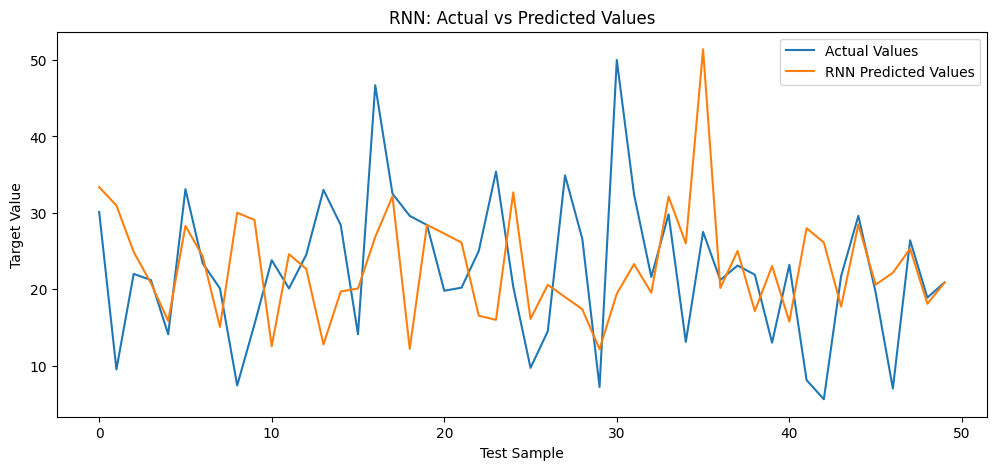

In [41]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_original[:50], label="Actual Values")
plt.plot(rnn_predictions_original[:50], label="RNN Predicted Values")

plt.title("RNN: Actual vs Predicted Values")
plt.xlabel("Test Sample")
plt.ylabel("Target Value")
plt.legend()
plt.show()

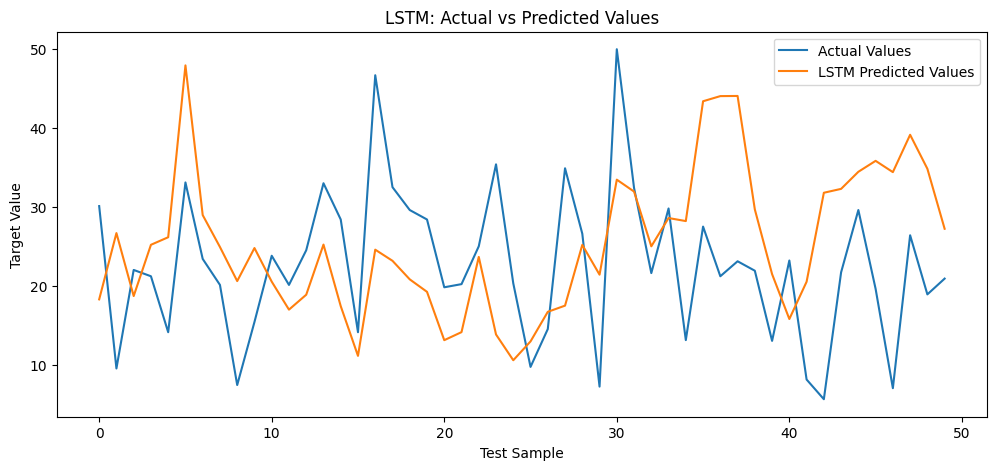

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_original[:50], label="Actual Values")
plt.plot(lstm_predictions_original[:50], label="LSTM Predicted Values")

plt.title("LSTM: Actual vs Predicted Values")
plt.xlabel("Test Sample")
plt.ylabel("Target Value")
plt.legend()
plt.show()

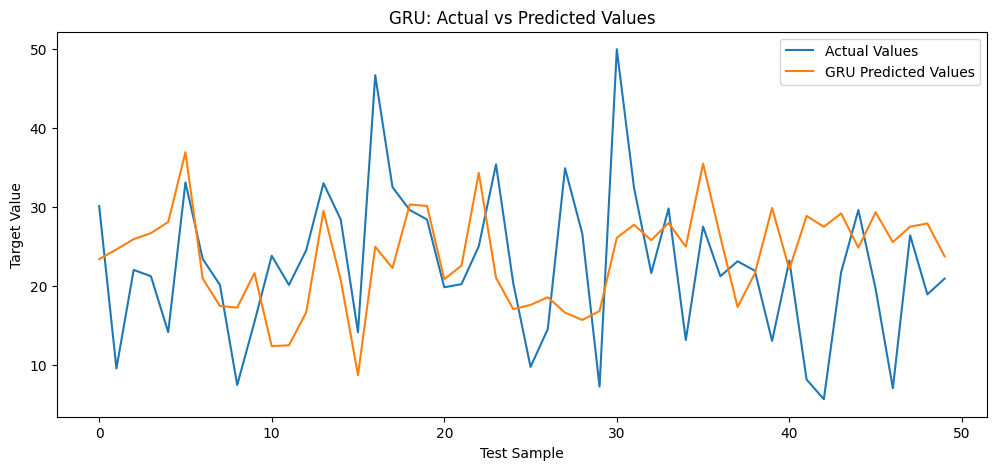

In [43]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_original[:50], label="Actual Values")
plt.plot(gru_predictions_original[:50], label="GRU Predicted Values")

plt.title("GRU: Actual vs Predicted Values")
plt.xlabel("Test Sample")
plt.ylabel("Target Value")
plt.legend()
plt.show()

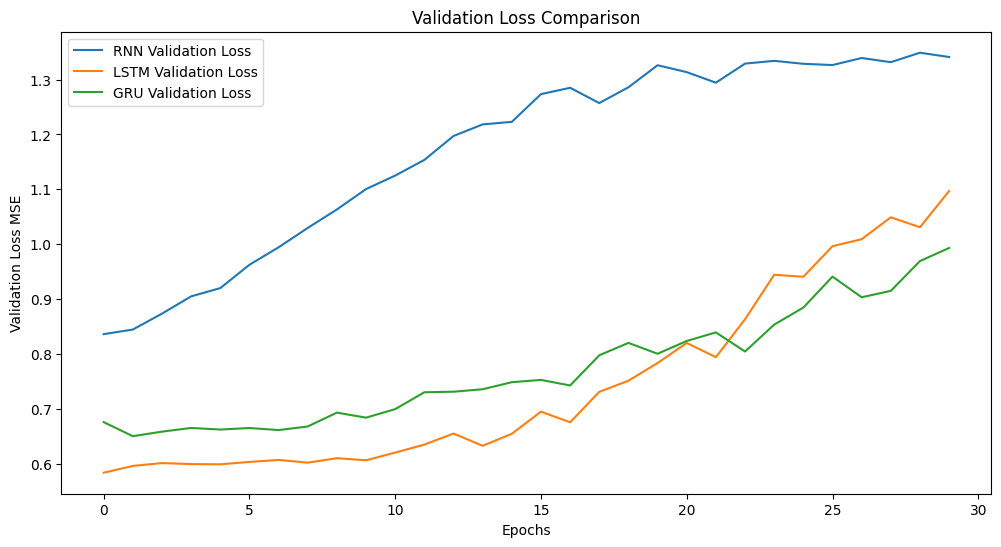

In [44]:
plt.figure(figsize=(12, 6))

plt.plot(rnn_history.history['val_loss'], label="RNN Validation Loss")
plt.plot(lstm_history.history['val_loss'], label="LSTM Validation Loss")
plt.plot(gru_history.history['val_loss'], label="GRU Validation Loss")

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss MSE")
plt.legend()
plt.show()

In [45]:
best_loss_model = final_results.loc[final_results["Test Loss MSE"].idxmin(), "Model"]
best_rmse_model = final_results.loc[final_results["RMSE Original Scale"].idxmin(), "Model"]
best_r2_model = final_results.loc[final_results["R2 Score"].idxmax(), "Model"]
fastest_model = final_results.loc[final_results["Training Time Seconds"].idxmin(), "Model"]

print("Best Model Based on Test Loss:", best_loss_model)
print("Best Model Based on RMSE:", best_rmse_model)
print("Best Model Based on R2 Score:", best_r2_model)
print("Fastest Model:", fastest_model)

Best Model Based on Test Loss: GRU
Best Model Based on RMSE: GRU
Best Model Based on R2 Score: GRU
Fastest Model: Simple RNN
